# Projeto Avaliativo – Análise de Dados com Python

## Fase 3 – Camada Gold: Análise de Dados

## Introdução



Este notebook apresenta a etapa de análise de dados (Camada Gold) do pipeline desenvolvido para o conjunto de dados Viagens a Serviço, disponibilizado pelo Portal da Transparência do Governo Federal.

Após a extração dos dados e sua transformação nas camadas Raw e Silver, são realizadas consultas analíticas para responder às perguntas de negócio propostas no projeto. As análises utilizam consultas SQL, tabelas e gráficos para transformar os dados tratados em informações que apoiam a compreensão dos gastos com viagens a serviço.

Além disso, é criada uma camada Gold com dados agregados, utilizando operações de JOIN e GROUP BY, permitindo a geração de indicadores voltados à tomada de decisão.

### Configuração do Ambiente e conexão com banco.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

import sys
sys.path.append("..")
import scripts.banco as banco

In [2]:
conexao = banco.conectar()

def consultar(sql):
    """Executa uma consulta SQL e retorna um DataFrame."""
    return pd.read_sql(sql, conexao)


def reais(valor):
    """Formata valores numéricos como moeda brasileira."""
    texto = f'{valor:,.2f}'
    return 'R$ ' + texto.replace(',', 'X').replace('.', ',').replace('X', '.')


print('Conectado ao MySQL com sucesso.')

Conectado ao MySQL com sucesso.


## Pergunta 1 – Quais são os 5 órgãos com maior custo total?


In [3]:
sql_q1 = '''
SELECT
    nome_orgao_superior AS orgao,
    SUM(valor_total) AS custo_total
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY custo_total DESC
LIMIT 5;
'''

q1 = consultar(sql_q1)

q1['custo_total_formatado'] = q1['custo_total'].apply(reais)

q1




,orgao,custo_total,custo_total_formatado
0,Ministério da Justiça e Segurança Pública,4.869331e+08,"R$ 486.933.121,65"
1,Ministério da Defesa,1.560703e+08,"R$ 156.070.304,49"
2,Ministério da Educação,1.112913e+08,"R$ 111.291.349,34"
3,Ministério do Meio Ambiente e Mudança do Clima,4.969771e+07,"R$ 49.697.710,16"
4,Ministério da Previdência Social,4.041731e+07,"R$ 40.417.309,06"


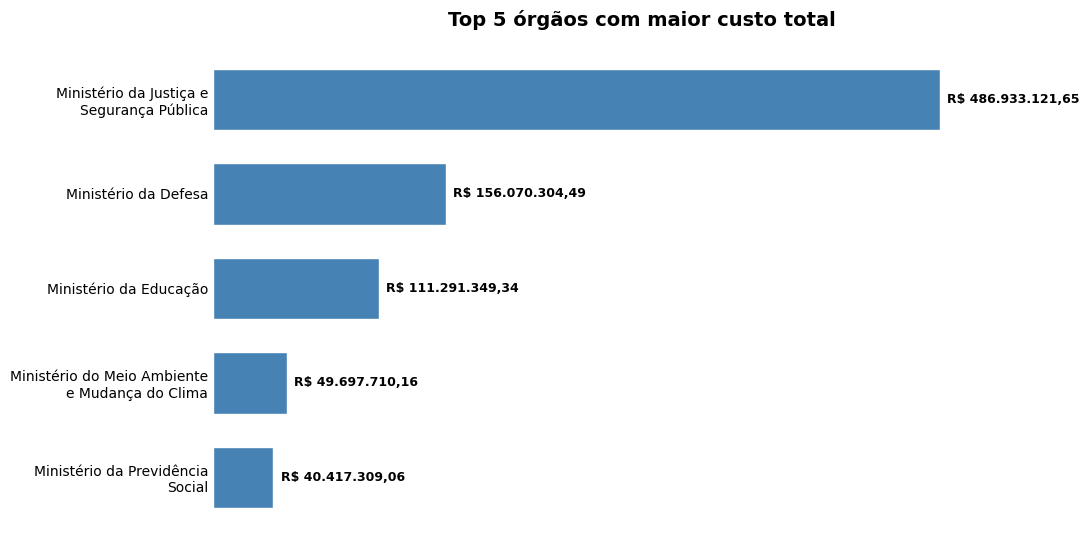

In [41]:
q1_grafico = q1.copy()

q1_grafico['orgao'] = q1_grafico['orgao'].apply(
    lambda x: textwrap.fill(x, width=28)
)

fig, ax = plt.subplots(figsize=(11, 5.5))


ax.barh(
    q1_grafico['orgao'],
    q1_grafico['custo_total'],
    color='steelblue',
    edgecolor='white',
    height=0.65
)


ax.invert_yaxis()


ax.set_xlim(0, q1['custo_total'].max() * 1.18)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)


ax.grid(False)
ax.set_xticks([])


ax.tick_params(axis='y', length=0)


ax.set_title(
    'Top 5 órgãos com maior custo total',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('')
ax.set_ylabel('')


for i, valor in enumerate(q1['custo_total']):
    ax.text(
        valor + q1['custo_total'].max() * 0.01,
        i,
        reais(valor),
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()

plt.savefig(
    "../assets/graficos/q1_valor_orgao.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Pergunta 2 – Quais são os 3 destinos com maior custo médio por viagem?

In [5]:
sql_q2 = '''
SELECT
    destino,
    AVG(valor_total) AS custo_medio,
    COUNT(*) AS quantidade_viagens
FROM (
    SELECT DISTINCT
        t.id_viagem,
        CONCAT(t.destino_cidade, '/', t.destino_uf) AS destino,
        v.valor_total
    FROM silver_trecho t
    INNER JOIN silver_viagem v
        ON t.id_viagem = v.id_viagem
    WHERE t.destino_cidade IS NOT NULL
      AND t.destino_cidade <> ''
      AND v.valor_total > 0
) AS viagens_destino
GROUP BY destino
HAVING COUNT(*) >= 30
ORDER BY custo_medio DESC
LIMIT 3;
'''

q2 = consultar(sql_q2)

q2['custo_medio_formatado'] = q2['custo_medio'].apply(reais)

q2

,destino,custo_medio,quantidade_viagens,custo_medio_formatado
0,Monte Negro/Rondônia,84926.029286,98,"R$ 84.926,03"
1,Sananduva/Rio Grande do Sul,78792.232233,103,"R$ 78.792,23"
2,Nonoai/Rio Grande do Sul,78603.743621,116,"R$ 78.603,74"


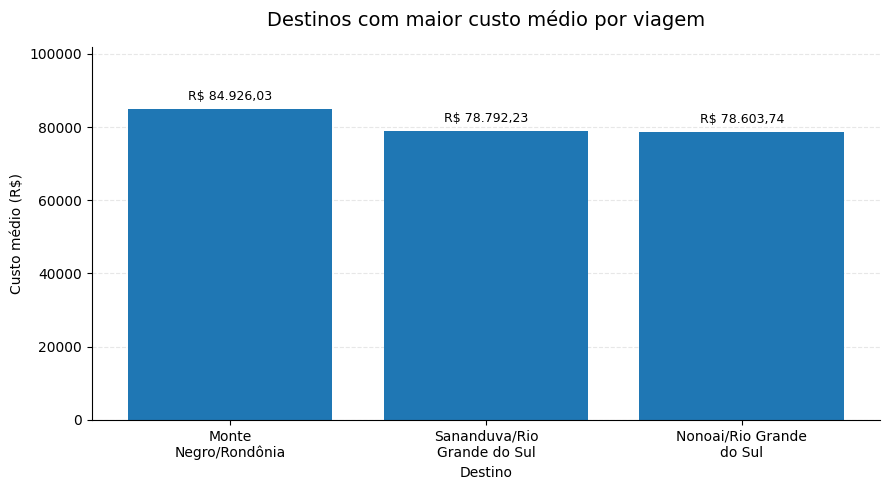

In [36]:
fig, ax = plt.subplots(figsize=(9, 5))


destinos = [
    '\n'.join(textwrap.wrap(nome, width=18))
    for nome in q2['destino']
]


ax.bar(
    destinos,
    q2['custo_medio']
)



ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_axisbelow(True)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)


ax.set_ylim(
    0,
    q2['custo_medio'].max() * 1.20
)

ax.set_title(
    'Destinos com maior custo médio por viagem',
    fontsize=14,
    pad=15
)


ax.set_xlabel('Destino')
ax.set_ylabel('Custo médio (R$)')



for i, valor in enumerate(q2['custo_medio']):
    ax.text(
        i,
        valor + q2['custo_medio'].max() * 0.02,
        reais(valor),
        ha='center',
        va='bottom',
        fontsize=9
    )


plt.tight_layout()

plt.savefig(
    "../assets/graficos/q2_destinos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 3 Maior duração registrada

In [7]:
sql_q3 = '''
SELECT
    id_viagem,
    nome_orgao_superior,
    duracao_dias,
    valor_total
FROM silver_viagem
ORDER BY duracao_dias DESC
LIMIT 1;
'''

q3 = consultar(sql_q3)

q3['valor_total_formatado'] = q3['valor_total'].apply(reais)

q3

,id_viagem,nome_orgao_superior,duracao_dias,valor_total,valor_total_formatado
0,0000000000020699856,Ministério da Previdência Social,383,0.0,"R$ 0,00"


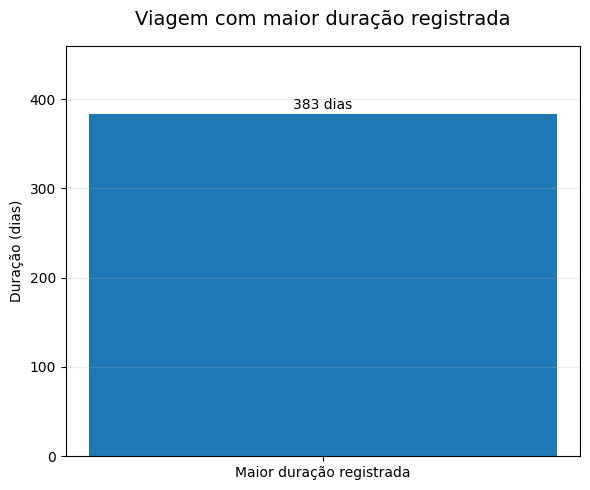

In [37]:
dados_grafico_q3 = pd.DataFrame({
    'categoria': ['Maior duração registrada'],
    'dias': [q3['duracao_dias'].iloc[0]]
})


fig, ax = plt.subplots(figsize=(6, 5))


ax.bar(
    dados_grafico_q3['categoria'],
    dados_grafico_q3['dias']
)


ax.set_title(
    'Viagem com maior duração registrada',
    fontsize=14,
    pad=15
)

ax.set_ylabel('Duração (dias)')
ax.set_xlabel('')



ax.set_ylim(
    0,
    dados_grafico_q3['dias'].iloc[0] * 1.20
)


ax.grid(
    axis='y',
    alpha=0.25
)


ax.text(
    0,
    dados_grafico_q3['dias'].iloc[0] + 2,
    f"{dados_grafico_q3['dias'].iloc[0]} dias",
    ha='center',
    va='bottom',
    fontsize=10
)


plt.tight_layout()

plt.savefig(
    "../assets/graficos/q3_maior_duracao.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Pergunta 4 – Qual o tipo de pagamento com maior valor médio?

In [9]:
sql_q4 = '''
SELECT
    tipo_pagamento,
    AVG(valor) AS valor_medio
FROM silver_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC;
'''

q4 = consultar(sql_q4)
q4['valor_medio_formatado'] = q4['valor_medio'].apply(reais)

q4

,tipo_pagamento,valor_medio,valor_medio_formatado
0,DIÁRIAS,2078.280299,"R$ 2.078,28"
1,PASSAGEM,1878.344393,"R$ 1.878,34"
2,Serviço correlato: seguro,447.514653,"R$ 447,51"
3,RESTITUIÇÃO,245.702610,"R$ 245,70"


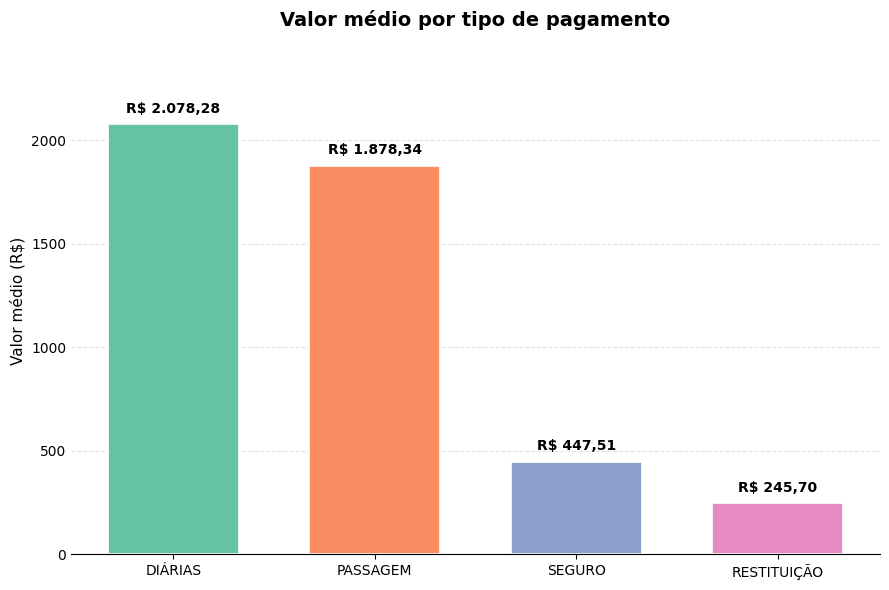

In [38]:
q4_grafico = q4.copy()

q4_grafico['tipo_pagamento'] = q4_grafico['tipo_pagamento'].replace(
    {'Serviço correlato: seguro': 'SEGURO'}
)

q4_grafico['tipo_pagamento'] = q4_grafico['tipo_pagamento'].apply(
    lambda x: textwrap.fill(x, width=18)
)

fig, ax = plt.subplots(figsize=(9, 6))

cores = sns.color_palette("Set2", n_colors=len(q4_grafico))

barras = ax.bar(
    q4_grafico["tipo_pagamento"],
    q4_grafico["valor_medio"],
    color=cores,
    width=0.65,
    edgecolor="white",
    linewidth=1.2
)

ax.set_ylim(0, q4_grafico["valor_medio"].max() * 1.18)

for barra, valor in zip(barras, q4["valor_medio"]):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + q4["valor_medio"].max() * 0.02,
        reais(valor),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Valor médio por tipo de pagamento",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Valor médio (R$)", fontsize=11)

ax.yaxis.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis='y', length=0)

plt.tight_layout()

plt.savefig(
    "../assets/graficos/q4_tipo_pagamento.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Pergunta 5 – Qual o meio de transporte mais usado nos trechos?

In [11]:
sql_q5 = '''
SELECT
    meio_transporte,
    COUNT(*) AS quantidade_trechos
FROM silver_trecho
GROUP BY meio_transporte
ORDER BY quantidade_trechos DESC;
'''

q5 = consultar(sql_q5)

q5

,meio_transporte,quantidade_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


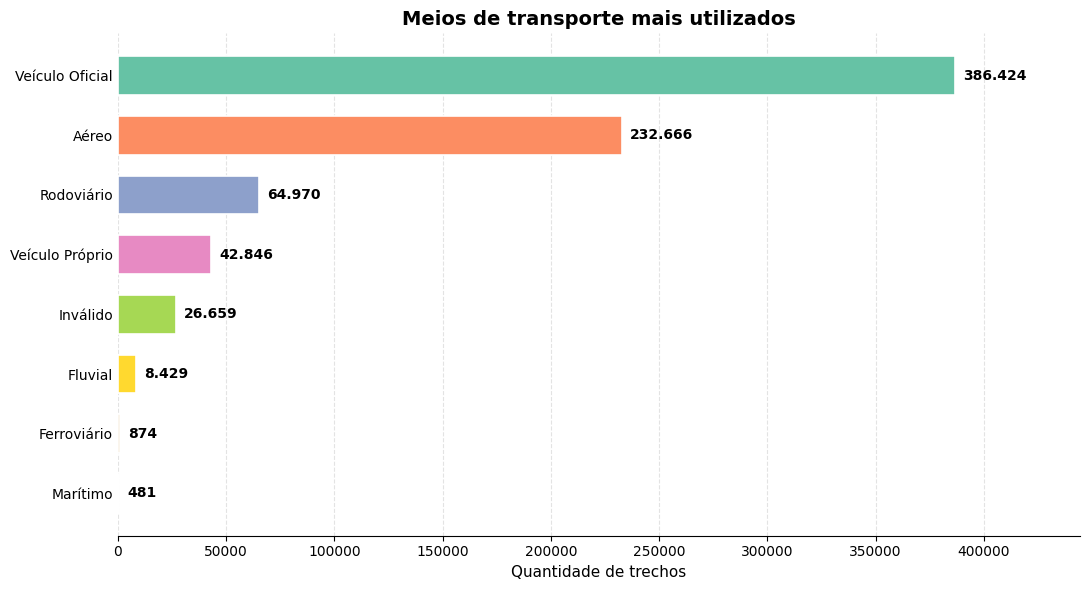

In [40]:
fig, ax = plt.subplots(figsize=(11, 6))


cores = sns.color_palette("Set2", n_colors=len(q5))


barras = ax.barh(
    q5["meio_transporte"],
    q5["quantidade_trechos"],
    color=cores,
    edgecolor="white",
    linewidth=1.2,
    height=0.65
)


ax.invert_yaxis()


ax.set_xlim(0, q5["quantidade_trechos"].max() * 1.15)


for barra in barras:
    largura = barra.get_width()

    ax.text(
        largura + q5["quantidade_trechos"].max() * 0.01,
        barra.get_y() + barra.get_height() / 2,
        f'{int(largura):,}'.replace(',', '.'),
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )


ax.set_title(
    "Meios de transporte mais utilizados",
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel("Quantidade de trechos", fontsize=11)
ax.set_ylabel("")


ax.xaxis.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


ax.tick_params(axis='y', length=0)

plt.tight_layout()

plt.savefig(
    "../assets/graficos/q5_meio_transporte.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Pergunta 6 – Qual UF de destino aparece em mais trechos?

In [13]:
sql_q6 = '''
SELECT
    destino_uf,
    COUNT(*) AS quantidade_trechos
FROM silver_trecho
WHERE destino_uf <> ''
  AND destino_uf <> 'Inválido'
GROUP BY destino_uf
ORDER BY quantidade_trechos DESC
LIMIT 10;
'''

q6 = consultar(sql_q6)

q6

,destino_uf,quantidade_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


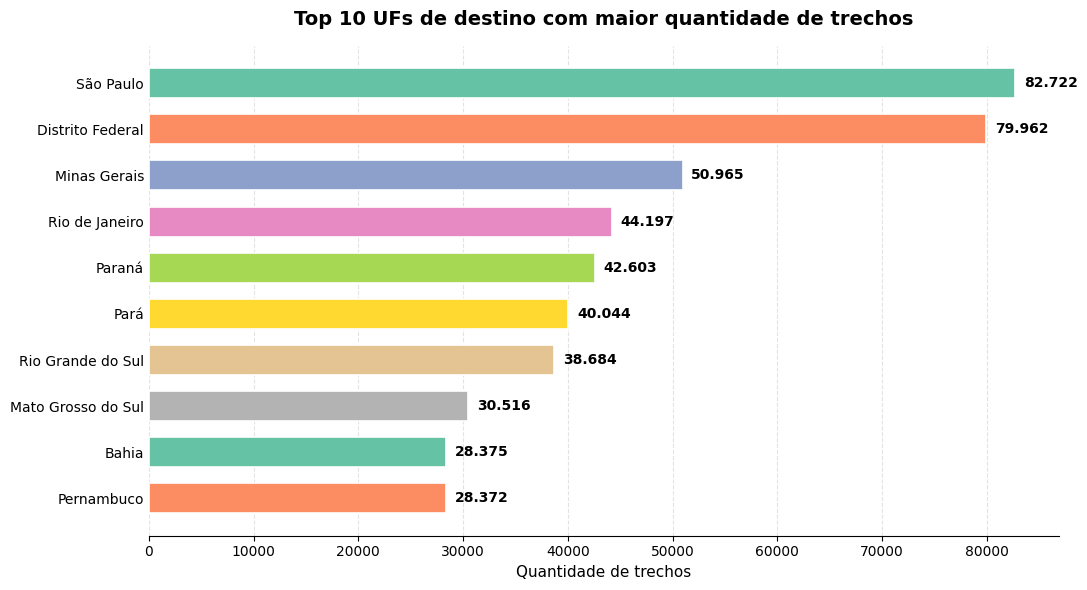

In [42]:
fig, ax = plt.subplots(figsize=(11, 6))

cores = sns.color_palette("Set2", n_colors=len(q6))

barras = ax.barh(
    q6["destino_uf"],
    q6["quantidade_trechos"],
    color=cores,
    edgecolor="white",
    linewidth=1.2,
    height=0.65
)

ax.invert_yaxis()

for barra in barras:

    largura = barra.get_width()

    ax.text(
        largura + q6["quantidade_trechos"].max() * 0.01,
        barra.get_y() + barra.get_height() / 2,
        f'{int(largura):,}'.replace(',', '.'),
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    "Top 10 UFs de destino com maior quantidade de trechos",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Quantidade de trechos", fontsize=11)
ax.set_ylabel("")

ax.xaxis.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis='y', length=0)

plt.tight_layout()

plt.savefig(
    "../assets/graficos/q6_destinos_uf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Criação da tabela Gold

A primeira etapa consiste na criação da tabela `gold_resumo_orgao`, construída a partir das tabelas `silver_viagem` e `silver_pagamento`, relacionadas pelo identificador da viagem (`id_viagem`).

A agregação é realizada por órgão superior, utilizando operações de JOIN e GROUP BY. Como resultado, a tabela consolida os seguintes indicadores:

- quantidade de viagens;
- quantidade de pagamentos;
- valor total pago;
- valor médio dos pagamentos.

Esses indicadores servem como base para consultas e análises da camada Gold.

In [15]:
banco.executar(conexao, "DROP TABLE IF EXISTS gold_resumo_orgao")

banco.executar(conexao, """
CREATE TABLE gold_resumo_orgao AS
SELECT
    v.nome_orgao_superior AS orgao,
    COUNT(DISTINCT v.id_viagem) AS total_viagens,
    COUNT(p.id_pagamento) AS total_pagamentos,
    SUM(p.valor) AS valor_total_pago,
    AVG(p.valor) AS valor_medio_pagamento
FROM silver_viagem AS v
INNER JOIN silver_pagamento AS p
    ON v.id_viagem = p.id_viagem
GROUP BY
    v.nome_orgao_superior;
""")

print("Tabela gold_resumo_orgao criada com sucesso.")

Tabela gold_resumo_orgao criada com sucesso.


### Validação Gold Resumo Orgão

In [16]:
gold = consultar("""
SELECT *
FROM gold_resumo_orgao
ORDER BY valor_total_pago DESC
LIMIT 10;
""")

gold

,orgao,total_viagens,total_pagamentos,valor_total_pago,valor_medio_pagamento
0,Ministério da Justiça e Segurança Pública,75633,175814,4.888311e+08,2780.387857
1,Ministério da Defesa,61388,93574,1.565498e+08,1673.004979
2,Ministério da Educação,60011,93340,1.118974e+08,1198.815453
3,Ministério do Meio Ambiente e Mudança do Clima,13397,26394,5.012304e+07,1899.031742
4,Ministério da Previdência Social,7911,20106,4.065949e+07,2022.256771
5,Ministério da Saúde,8185,18914,3.951792e+07,2089.347469
6,Ministério da Fazenda,11760,23613,3.266602e+07,1383.391243
7,Ministério dos Povos Indígenas,5046,10618,2.644114e+07,2490.218704
8,Ministério das Relações Exteriores,1944,3757,2.572434e+07,6847.042097
9,Ministério do Desenvolvimento Agrário e Agricu...,7782,13247,2.217168e+07,1673.713556


### Criação da View 

In [17]:
banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_resumo_orgao")

banco.executar(conexao, """
CREATE VIEW vw_gold_resumo_orgao AS
SELECT
    orgao,
    total_viagens,
    total_pagamentos,
    valor_total_pago,
    valor_medio_pagamento
FROM gold_resumo_orgao;
""")

print("VIEW criada com sucesso.")

VIEW criada com sucesso.


### Validação View Resumo Orgão

In [18]:
gold_view = consultar("""
SELECT *
FROM vw_gold_resumo_orgao
ORDER BY valor_total_pago DESC
LIMIT 10;
""")

gold_view

,orgao,total_viagens,total_pagamentos,valor_total_pago,valor_medio_pagamento
0,Ministério da Justiça e Segurança Pública,75633,175814,4.888311e+08,2780.387857
1,Ministério da Defesa,61388,93574,1.565498e+08,1673.004979
2,Ministério da Educação,60011,93340,1.118974e+08,1198.815453
3,Ministério do Meio Ambiente e Mudança do Clima,13397,26394,5.012304e+07,1899.031742
4,Ministério da Previdência Social,7911,20106,4.065949e+07,2022.256771
5,Ministério da Saúde,8185,18914,3.951792e+07,2089.347469
6,Ministério da Fazenda,11760,23613,3.266602e+07,1383.391243
7,Ministério dos Povos Indígenas,5046,10618,2.644114e+07,2490.218704
8,Ministério das Relações Exteriores,1944,3757,2.572434e+07,6847.042097
9,Ministério do Desenvolvimento Agrário e Agricu...,7782,13247,2.217168e+07,1673.713556


## Pergunta 7 – Qual órgão pagou mais no total?

In [19]:
sql_q7 = '''
SELECT
    orgao,
    valor_total_pago
FROM vw_gold_resumo_orgao
ORDER BY valor_total_pago DESC
LIMIT 10;
'''

q7 = consultar(sql_q7)

q7['valor_total_formatado'] = q7['valor_total_pago'].apply(reais)

q7

,orgao,valor_total_pago,valor_total_formatado
0,Ministério da Justiça e Segurança Pública,4.888311e+08,"R$ 488.831.110,61"
1,Ministério da Defesa,1.565498e+08,"R$ 156.549.767,91"
2,Ministério da Educação,1.118974e+08,"R$ 111.897.434,35"
3,Ministério do Meio Ambiente e Mudança do Clima,5.012304e+07,"R$ 50.123.043,80"
4,Ministério da Previdência Social,4.065949e+07,"R$ 40.659.494,63"
5,Ministério da Saúde,3.951792e+07,"R$ 39.517.918,03"
6,Ministério da Fazenda,3.266602e+07,"R$ 32.666.017,41"
7,Ministério dos Povos Indígenas,2.644114e+07,"R$ 26.441.142,20"
8,Ministério das Relações Exteriores,2.572434e+07,"R$ 25.724.337,16"
9,Ministério do Desenvolvimento Agrário e Agricu...,2.217168e+07,"R$ 22.171.683,47"


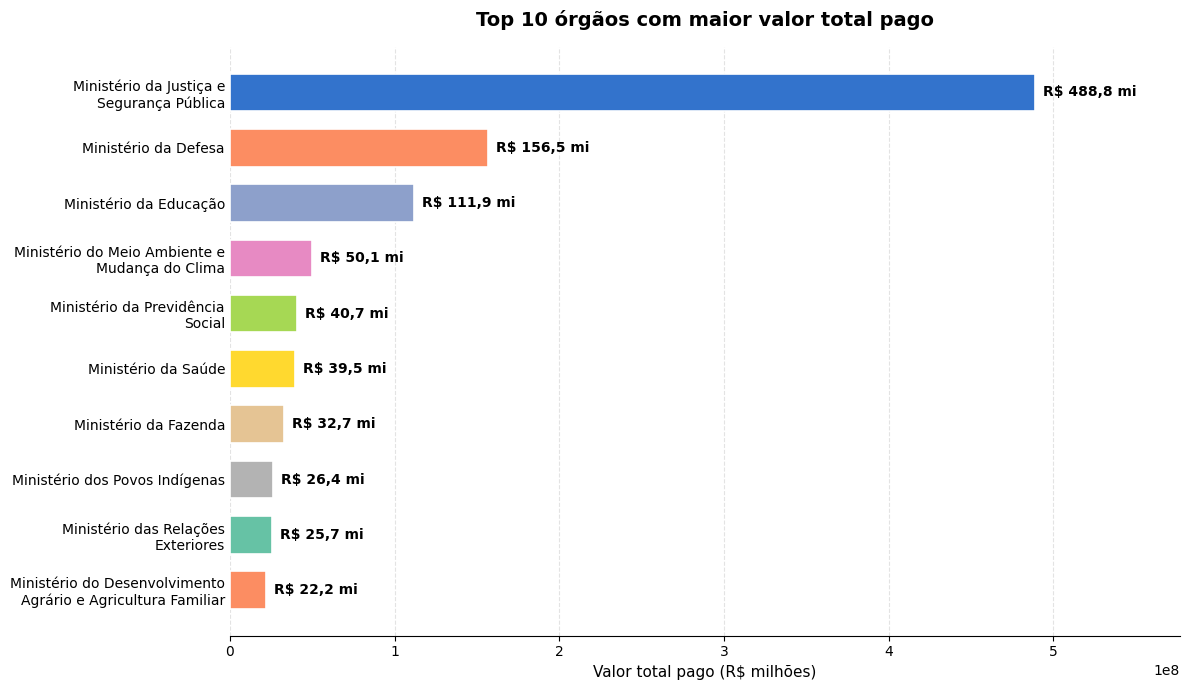

In [43]:
q7_grafico = q7.copy()


q7_grafico["orgao"] = q7_grafico["orgao"].apply(
    lambda x: textwrap.fill(x, width=30)
)

fig, ax = plt.subplots(figsize=(12, 7))

cores = sns.color_palette("Set2", n_colors=len(q7_grafico))

cores[0] = (0.20, 0.45, 0.80)

barras = ax.barh(
    q7_grafico["orgao"],
    q7_grafico["valor_total_pago"],
    color=cores,
    edgecolor="white",
    linewidth=1.2,
    height=0.68
)


ax.invert_yaxis()


ax.set_xlim(0, q7_grafico["valor_total_pago"].max() * 1.18)


for barra in barras:

    largura = barra.get_width()

    ax.text(
        largura + q7_grafico["valor_total_pago"].max() * 0.01,
        barra.get_y() + barra.get_height()/2,
        f'R$ {largura / 1_000_000:.1f} mi'.replace('.', ','),
        # reais_milhoes(largura),
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Top 10 órgãos com maior valor total pago",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Valor total pago (R$ milhões)", fontsize=11)
ax.set_ylabel("")

ax.xaxis.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", length=0)

plt.tight_layout()

plt.savefig(
    "../assets/graficos/q7_valor_orgao.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Camada Gold – Tipo de Pagamento

A tabela `gold_tipo_pagamento` consolida as informações da tabela `silver_pagamento`, agrupando os registros por tipo de pagamento e calculando indicadores que permitem análises gerenciais.

Os indicadores gerados são:

- quantidade de pagamentos;
- valor total pago;
- valor médio dos pagamentos.

Essa estrutura evita a necessidade de recalcular essas agregações sempre que a análise for realizada.

In [21]:
banco.executar(conexao, "DROP TABLE IF EXISTS gold_tipo_pagamento")

banco.executar(conexao, """
CREATE TABLE gold_tipo_pagamento AS
SELECT
    tipo_pagamento,
    COUNT(*) AS quantidade_pagamentos,
    SUM(valor) AS valor_total_pago,
    AVG(valor) AS valor_medio
FROM silver_pagamento
GROUP BY tipo_pagamento;
""")

print("Tabela gold_tipo_pagamento criada com sucesso.")

Tabela gold_tipo_pagamento criada com sucesso.


### Validação Gold Tipo Pagamento

In [22]:
consultar("""
SELECT *
FROM gold_tipo_pagamento
ORDER BY valor_medio DESC;
""")

,tipo_pagamento,quantidade_pagamentos,valor_total_pago,valor_medio
0,DIÁRIAS,401463,8.343526e+08,2078.280299
1,PASSAGEM,188985,3.549789e+08,1878.344393
2,Serviço correlato: seguro,4894,2.190137e+06,447.514653
3,RESTITUIÇÃO,11574,2.843762e+06,245.702610


### Criação da View Tipo de Pagamento

In [23]:
banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_tipo_pagamento")

banco.executar(conexao, """
CREATE VIEW vw_gold_tipo_pagamento AS
SELECT *
FROM gold_tipo_pagamento;
""")

print("VIEW vw_gold_tipo_pagamento criada com sucesso.")

VIEW vw_gold_tipo_pagamento criada com sucesso.


### Validação View Tipo Pagamento

In [24]:
consultar("""
SELECT *
FROM vw_gold_tipo_pagamento
ORDER BY valor_medio DESC;
""")

,tipo_pagamento,quantidade_pagamentos,valor_total_pago,valor_medio
0,DIÁRIAS,401463,8.343526e+08,2078.280299
1,PASSAGEM,188985,3.549789e+08,1878.344393
2,Serviço correlato: seguro,4894,2.190137e+06,447.514653
3,RESTITUIÇÃO,11574,2.843762e+06,245.702610


## Camada Gold – Meio de Transporte

A tabela `gold_meio_transporte` consolida as informações da tabela `silver_trecho`, agrupando os registros por meio de transporte.

Como resultado, são obtidos indicadores que permitem identificar a frequência de utilização de cada modalidade de transporte.

In [25]:
banco.executar(conexao, "DROP TABLE IF EXISTS gold_meio_transporte")

banco.executar(conexao, """
CREATE TABLE gold_meio_transporte AS
SELECT
    meio_transporte,
    COUNT(*) AS quantidade_trechos
FROM silver_trecho
GROUP BY meio_transporte;
""")

print("Tabela gold_meio_transporte criada com sucesso.")

Tabela gold_meio_transporte criada com sucesso.


### Validação Camada Gold Meio de Transporte

In [26]:
consultar("""
SELECT *
FROM gold_meio_transporte
ORDER BY quantidade_trechos DESC;
""")

,meio_transporte,quantidade_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


### Criação da View Meio de Transporte 

In [27]:
banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_meio_transporte")

banco.executar(conexao, """
CREATE VIEW vw_gold_meio_transporte AS
SELECT *
FROM gold_meio_transporte;
""")

print("VIEW vw_gold_meio_transporte criada com sucesso.")

VIEW vw_gold_meio_transporte criada com sucesso.


### Validação da VIEW  Meio de Transporte

In [28]:
consultar("""
SELECT *
FROM vw_gold_meio_transporte
ORDER BY quantidade_trechos DESC;
""")

,meio_transporte,quantidade_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


## Camada Gold – UF de Destino

A tabela `gold_destino_uf` consolida os registros da tabela `silver_trecho`, agrupando os trechos pela UF de destino.

Como resultado, são obtidos indicadores que permitem identificar os estados que receberam a maior quantidade de deslocamentos.

In [29]:
banco.executar(conexao, "DROP TABLE IF EXISTS gold_destino_uf")

banco.executar(conexao, """
CREATE TABLE gold_destino_uf AS
SELECT
    destino_uf,
    COUNT(*) AS quantidade_trechos
FROM silver_trecho
WHERE destino_uf IS NOT NULL
  AND destino_uf <> ''
GROUP BY destino_uf;
""")

print("Tabela gold_destino_uf criada com sucesso.")

Tabela gold_destino_uf criada com sucesso.


### Validação camada Gold Destino

In [33]:
consultar("""
SELECT *
FROM gold_destino_uf
ORDER BY quantidade_trechos DESC
LIMIT 10;
""")

,destino_uf,quantidade_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


### Criação da View Destino

In [31]:
banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_destino_uf")

banco.executar(conexao, """
CREATE VIEW vw_gold_destino_uf AS
SELECT *
FROM gold_destino_uf;
""")

print("VIEW vw_gold_destino_uf criada com sucesso.")

VIEW vw_gold_destino_uf criada com sucesso.


### Validação da View Destino

In [34]:
consultar("""
SELECT *
FROM vw_gold_destino_uf
ORDER BY quantidade_trechos DESC
LIMIT 10;
""")

,destino_uf,quantidade_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


In [ ]:
conexao.close()
print("Conexão encerrada.")